In [14]:
import os
from dotenv import load_dotenv
from typing_extensions import TypedDict, Literal
from typing import List
from langgraph.types import Command
from langgraph.graph import START, END, StateGraph
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

load_dotenv()

llm = init_chat_model("openai:gpt-4o-mini")

ai_msg = llm.invoke("준비됬니?")
print(ai_msg.content)

네, 준비되었습니다! 무엇을 도와드릴까요?


In [23]:

llm_lv_1 = init_chat_model("openai:gpt-4o-mini")
llm_lv_2 = init_chat_model("openai:gpt-4o")
llm_lv_3 = init_chat_model("openai:gpt-5-2025-08-07")

In [16]:
class State(TypedDict) :
    question : str
    difficulty : str
    answer : str
    model_used : str

class DifficultyResponse(BaseModel):
    difficulty_level : Literal["easy", "medium", "hard"]


In [17]:
def node_level_1(state : State):
    res = llm_lv_1.invoke(state["question"])

    return {
        "answer" : res.content,
        "model_used" : "gpt-o3"
    }

def node_level_2(state: State):
    res = llm_lv_2.invoke(state["question"])

    return {
        "answer" : res.content,
        "model_used" : "gpt-4o"
    }    

def node_level_3(state : State):
    res = llm_lv_3.invoke(state["question"])    

    return {
        "answer" : res.content,
        "model_used" : "gpt-5"
    }

# 난이도 평가
def node_assess_dificulty(state : State):

    difficulty_llm = llm.with_structured_output(DifficultyResponse)

    difficulty_res = difficulty_llm.invoke(
        f"""
            Assess the difficulty of this question
            Question : {state["question"]}

            - EASY : Simple facts, basic definitions, yes/no answers
            - MEDIUM : Requires explanation, comparison, analysis
            - HARD : Complex reasoning, multiple steps, deep expertise
        """
    )

    difficulty_level = difficulty_res.difficulty_level

    if difficulty_level == "easy" :
        goto = "node_level_1"
    elif difficulty_level == "medium":
        goto = "node_level_2"
    elif difficulty_level == "hard":
        goto = "node_level_3"
    else :
        goto = "node_level_1"

    return Command(
        goto=goto,
        update = {
            "difficulty" : difficulty_level
        }
    )    


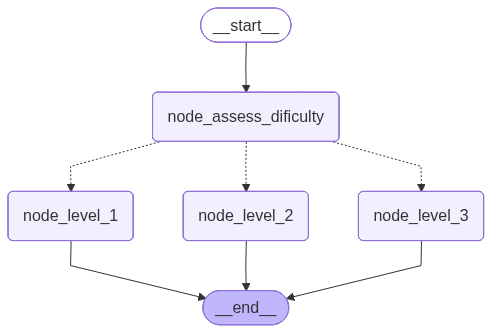

In [18]:
graph_builder = StateGraph(State)

graph_builder.add_node("node_level_1",node_level_1)
graph_builder.add_node("node_level_2",node_level_2)
graph_builder.add_node("node_level_3",node_level_3)
graph_builder.add_node("node_assess_dificulty", node_assess_dificulty, destinations = ("node_level_1","node_level_2","node_level_3"))

graph_builder.add_edge(
    START,
    "node_assess_dificulty"
)
graph_builder.add_edge("node_level_1", END)
graph_builder.add_edge("node_level_2", END)
graph_builder.add_edge("node_level_3", END)

graph = graph_builder.compile()

graph





In [19]:
graph.invoke({
    "question" : """ 현재 2026.03.31 기준의 전세계적 경제 및 외교상황을 고려하여 2026년 4월의 미국 증시는 어떨지, 상승할 것으로 예상되는 좋은 종목이 있는지 말해줘 """
})

d:\DMS\dms260210\Project\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DifficultyResponse(difficulty_level='hard'), input_type=DifficultyResponse])
  return self.__pydantic_serializer__.to_python(


{'question': ' 현재 2026.03.31 기준의 전세계적 경제 및 외교상황을 고려하여 2026년 4월의 미국 증시는 어떨지, 상승할 것으로 예상되는 좋은 종목이 있는지 말해줘 ',
 'difficulty': 'hard',
 'answer': '먼저 제 한계부터 말씀드립니다. 저는 2024년 10월 이후의 실시간 데이터나 2026년 3월 말의 확정된 뉴스·지표를 직접 확인할 수 없습니다. 아래 내용은 일반적으로 4월에 시장을 움직이는 요인과 최근 수년간의 추세를 바탕으로 한 시나리오별 접근과 테마/종목 아이디어입니다. 투자 조언이 아닌 정보 제공이며, 단기(한 달) 방향성은 변동성이 크다는 점을 유의해 주세요.\n\n4월 미국 증시의 큰 변수를 어떻게 볼까\n- 거시/정책: 4월은 1분기 실적 시즌 초입(대형은행→메가캡 기술주), 같은 시기 발표되는 인플레이션 지표(CPI/PPI/PCE)와 장기금리 흐름이 방향성을 좌우하는 경우가 많습니다. 연준의 금리 전망(동결 vs 하반기 인하 기대)과 재정/국채 발행에 따른 금리 압력도 중요합니다.\n- 지정학: 에너지 가격을 자극할 중동/러-우 사안, 방산 수요/공급망 이슈, 미-중 기술·무역 긴장(반도체·AI 장비/소재)에 따른 개별 업종 변동성이 커질 수 있습니다.\n\n가능한 시나리오(요약)\n- 기준 시나리오(확률 중간): 인플레가 점진 둔화, 연준은 인하 기대를 유지하되 “서두르지 않는” 톤. 실적은 혼조지만 대형주가 방어. 지수는 박스권~완만한 상승, 리더십은 AI/전력·전기설비/질적 성장주.\n- 상방 시나리오: 인플레 서프라이즈 둔화 + 대형 기술주/은행 실적 호조 → 장기금리 하락, 성장·모멘텀·중소형 기술주 동반 랠리.\n- 하방 시나리오: 물가 재가열·유가 급등 또는 지정학 충격/실적 쇼크 → 금리 상승과 밸류에이션 압박. 방산·에너지·필수소비재·유틸리티 방어, 고밸류 성장주 조정.\n\n4월에 상대적 강세를 기대할 수 있는 테마와 종목 아이디어\n(각 종목은 미국 상장 기준, 간단 논리와 

In [21]:
graph.invoke({
    "question" : "프로그래밍에서 사용하는 proxy 라는 용어에 대해서 설명해줘줘"
})

d:\DMS\dms260210\Project\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DifficultyResponse(difficulty_level='medium'), input_type=DifficultyResponse])
  return self.__pydantic_serializer__.to_python(


{'question': '프로그래밍에서 사용하는 proxy 라는 용어에 대해서 설명해줘줘',
 'difficulty': 'medium',
 'answer': '프로그래밍에서 "프록시(proxy)"라는 용어는 대리자나 중개자의 역할을 하는 디자인 패턴이나 객체를 가리킵니다. 프록시는 다른 객체에 대한 접근을 제어하거나 그 접근을 단순화하기 위해 사용됩니다. 프록시 패턴은 다양한 상황에서 유용하게 사용될 수 있으며, 다음과 같은 주요 유형들이 있습니다:\n\n1. **가상 프록시 (Virtual Proxy)**: 실제 객체의 생성 비용이 높은 경우 필요한 시점까지 객체 생성을 지연시키는 방식입니다. 예를 들어, 이미지 뷰어 어플리케이션에서 이미지 파일을 열 때 실제 이미지를 메모리에 로드하기 전에 이미지 정보(크기, 이름 등)만 먼저 로드하는 방법이 있습니다.\n\n2. **원격 프록시 (Remote Proxy)**: 원격 서버에 위치한 객체에 접근하는 경우 사용됩니다. 클라이언트는 마치 로컬에 있는 객체처럼 프록시를 통해 원격 객체에 접근할 수 있습니다. 이는 주로 분산 컴퓨팅 환경에서 사용됩니다.\n\n3. **보호 프록시 (Protection Proxy)**: 객체에 대한 접근 제어를 수행하며, 권한에 따라 접근을 제한할 때 사용됩니다. 예를 들어, 사용자의 역할에 따라 접근할 수 있는 메서드를 제한할 수 있습니다.\n\n4. **스마트 프록시 (Smart Proxy)**: 추가적인 기능이나 작업을 수행하는 프록시입니다. 예를 들어, 접근 횟수를 기록하거나 객체에 접근할 때마다 로깅을 수행할 수 있습니다.\n\n프록시 패턴은 객체에 대한 접근을 제어하고 관리하는 데 유용하며, 성능 최적화, 보안 강화, 네트워크 트래픽 감소 등의 이유로 활용될 수 있습니다. 각 프록시 유형은 특정한 문제를 해결하고자 할 때 적절하게 선택하여 사용할 수 있습니다.',
 'model_used': 'gpt-4o'}

In [24]:
graph.invoke({
    "question" : "버섯은 채소인가?"
})

d:\DMS\dms260210\Project\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DifficultyResponse(difficulty_level='easy'), input_type=DifficultyResponse])
  return self.__pydantic_serializer__.to_python(


{'question': '버섯은 채소인가?',
 'difficulty': 'easy',
 'answer': '버섯은 채소가 아니라 균류(Fungi)에 속하는 생물입니다. 일반적으로 우리가 식용으로 사용하는 버섯은 다양한 영양소를 포함하고 있으며, 채소와 함께 요리에 사용되기도 하지만, 생물학적으로는 채소와는 다른 분류에 속합니다. 버섯은 광합성을 하지 않으며, 유기물에서 영양분을 흡수하여 성장합니다.',
 'model_used': 'gpt-o3'}